In [26]:
print("E-Commerce Analytics Project Started!")

E-Commerce Analytics Project Started!


In [28]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/superstore.csv",
    encoding="latin-1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 9994
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [29]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [30]:
df.shape

(9994, 21)

In [31]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [32]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [33]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [37]:
clean_df = df.copy()

print("Original dataset:", df.shape)
print("Working dataset:", clean_df.shape)

Original dataset: (9994, 21)
Working dataset: (9994, 21)


In [38]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

clean_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')

In [39]:
clean_df["sales"]

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9989     25.2480
9990     91.9600
9991    258.5760
9992     29.6000
9993    243.1600
Name: sales, Length: 9994, dtype: float64

In [40]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [41]:
clean_df = clean_df.drop_duplicates()

print("Dataset after removing duplicates:", clean_df.shape)

Dataset after removing duplicates: (9994, 21)


In [42]:
missing_values = clean_df.isnull().sum()

print(missing_values)

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


In [43]:
clean_df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [44]:
"order_date" in clean_df.columns

True

In [45]:
# Create a fresh copy of the new dataset
clean_df = df.copy()

print("Original rows:", len(df))
print("Original columns:", len(df.columns))

Original rows: 9994
Original columns: 21


In [46]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(clean_df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [47]:
clean_df["order_date"] = pd.to_datetime(
    clean_df["order_date"],
    errors="coerce"
)

clean_df["ship_date"] = pd.to_datetime(
    clean_df["ship_date"],
    errors="coerce"
)

print("Order Date type:", clean_df["order_date"].dtype)
print("Ship Date type:", clean_df["ship_date"].dtype)

Order Date type: datetime64[us]
Ship Date type: datetime64[us]


In [48]:
missing_values = clean_df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [49]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [50]:
clean_df.to_csv(
    "../data/cleaned/superstore_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [51]:
print("Final dataset shape:", clean_df.shape)

Final dataset shape: (9994, 21)


# Exploratory Data Analysis

This section analyzes sales, profit, customers, products, regions, and discounts to identify important business patterns and insights.

In [52]:
# Key Business KPIs

total_sales = clean_df["sales"].sum()
total_profit = clean_df["profit"].sum()
total_orders = clean_df["order_id"].nunique()
total_customers = clean_df["customer_id"].nunique()
total_products = clean_df["product_id"].nunique()
total_quantity = clean_df["quantity"].sum()
average_order_value = total_sales / total_orders

print("===== E-COMMERCE BUSINESS KPIs =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

===== E-COMMERCE BUSINESS KPIs =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Total Products: 1,862
Total Quantity Sold: 37,873
Average Order Value: $458.61


In [53]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Quantity",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        total_products,
        total_quantity,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Total Products,1.862000e+03
5,Total Quantity,3.787300e+04
6,Average Order Value,4.586147e+02


In [54]:
category_analysis = (
    clean_df
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("sales", ascending=False)
)

category_analysis

,sales,profit,quantity,orders
category,,,,
Technology,836154.0330,145454.9481,6939,1544
Furniture,741999.7953,18451.2728,8028,1764
Office Supplies,719047.0320,122490.8008,22906,3742


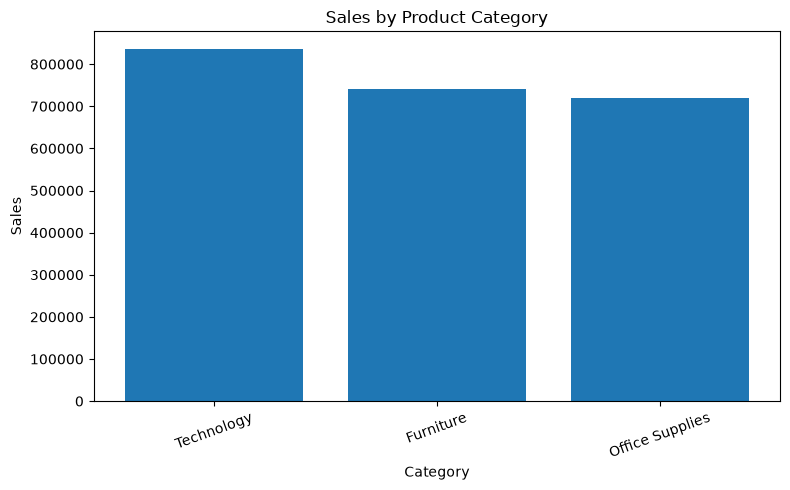

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

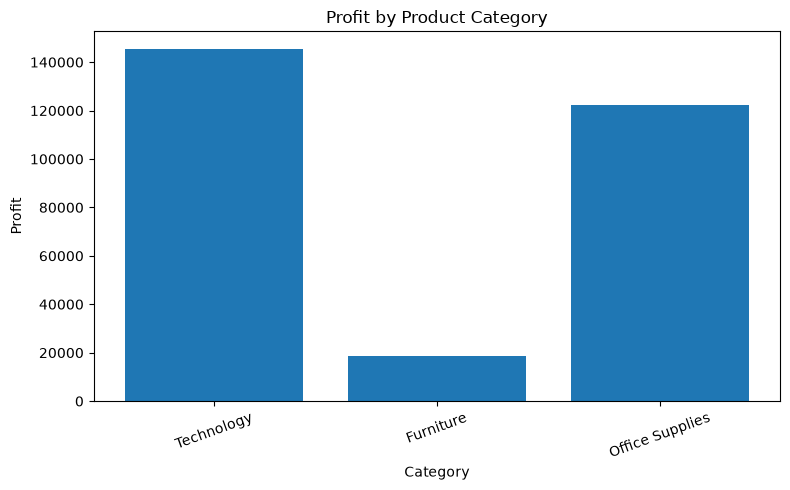

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [57]:
product_analysis = (
    clean_df
    .groupby(["product_id", "product_name"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("profit", ascending=False)
)

product_analysis.head(10)

,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31,10
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12,3
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24,7
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3


In [58]:
loss_making_products = (
    product_analysis[
        product_analysis["profit"] < 0
    ]
    .sort_values("profit")
)

loss_making_products.head(10)

,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27,5
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33,7
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6,1
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22,6
FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4


In [59]:
clean_df[["order_date", "sales", "profit"]].head()

,order_date,sales,profit
0,2016-11-08,261.9600,41.9136
1,2016-11-08,731.9400,219.5820
2,2016-06-12,14.6200,6.8714
3,2015-10-11,957.5775,-383.0310
4,2015-10-11,22.3680,2.5164


In [60]:
clean_df["year"] = clean_df["order_date"].dt.year
clean_df["month"] = clean_df["order_date"].dt.month
clean_df["month_name"] = clean_df["order_date"].dt.month_name()

In [61]:
yearly_analysis = (
    clean_df
    .groupby("year")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
)

yearly_analysis

,sales,profit,orders
year,,,
2014,484247.4981,49543.9741,969
2015,470532.5090,61618.6037,1038
2016,609205.5980,81795.1743,1315
2017,733215.2552,93439.2696,1687


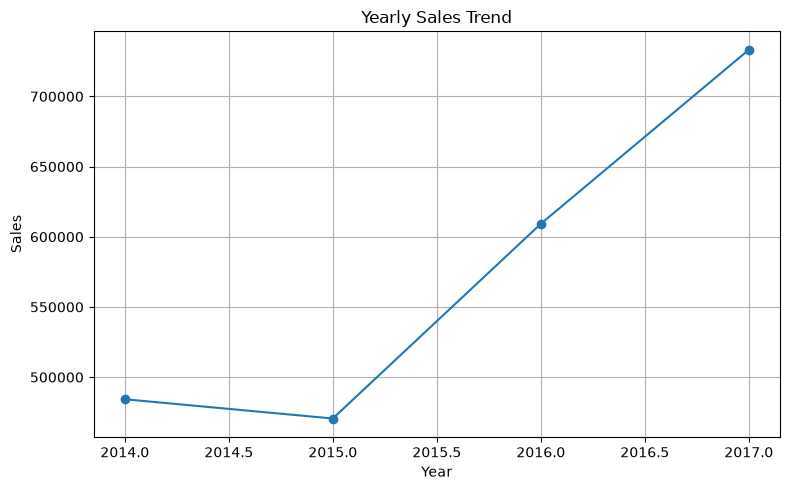

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_analysis.index,
    yearly_analysis["sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)
plt.tight_layout()

plt.show()

In [63]:
monthly_analysis = (
    clean_df
    .groupby(["year", "month"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_analysis.head(12)

,year,month,sales,profit,orders
0,2014,1,14236.8950,2450.1907,32
1,2014,2,4519.8920,862.3084,28
2,2014,3,55691.0090,498.7299,71
3,2014,4,28295.3450,3488.8352,66
4,2014,5,23648.2870,2738.7096,69
5,2014,6,34595.1276,4976.5244,66
6,2014,7,33946.3930,-841.4826,65
7,2014,8,27909.4685,5318.1050,72
8,2014,9,81777.3508,8328.0994,130
9,2014,10,31453.3930,3448.2573,78


In [64]:
monthly_analysis["date"] = pd.to_datetime(
    monthly_analysis["year"].astype(str)
    + "-"
    + monthly_analysis["month"].astype(str)
    + "-01"
)

monthly_analysis.head()

,year,month,sales,profit,orders,date
0,2014,1,14236.895,2450.1907,32,2014-01-01
1,2014,2,4519.892,862.3084,28,2014-02-01
2,2014,3,55691.009,498.7299,71,2014-03-01
3,2014,4,28295.345,3488.8352,66,2014-04-01
4,2014,5,23648.287,2738.7096,69,2014-05-01


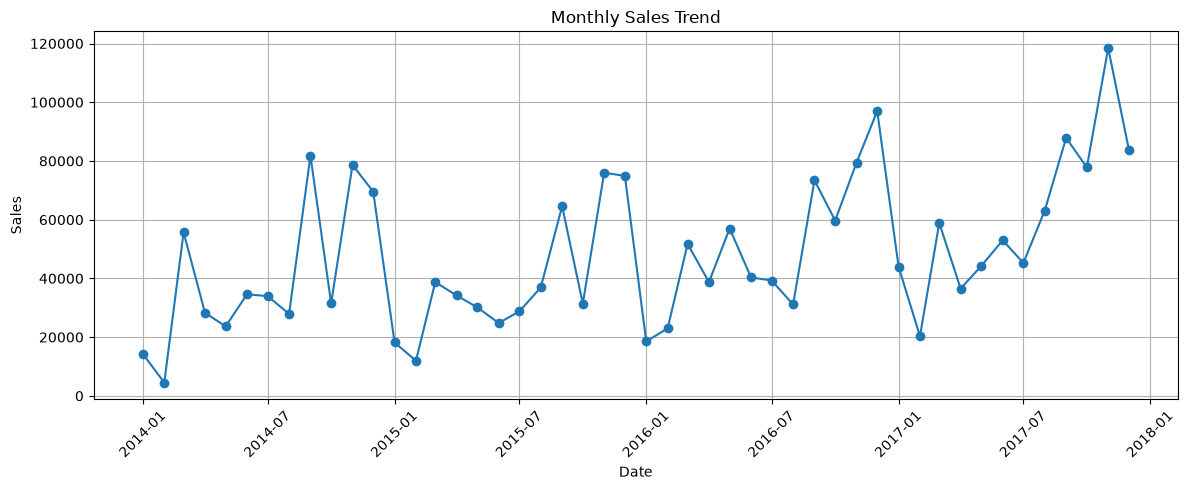

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["date"],
    monthly_analysis["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

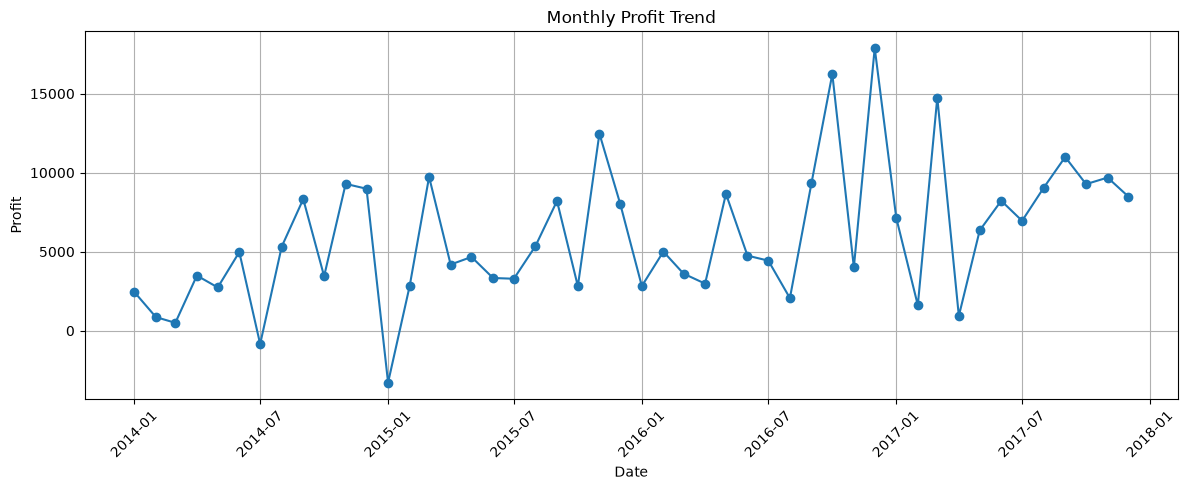

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["date"],
    monthly_analysis["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [67]:
best_sales_month = monthly_analysis.loc[
    monthly_analysis["sales"].idxmax()
]

best_sales_month

year                     2017
month                      11
sales              118447.825
profit              9690.1037
orders                    261
date      2017-11-01 00:00:00
Name: 46, dtype: object

In [68]:
best_profit_month = monthly_analysis.loc[
    monthly_analysis["profit"].idxmax()
]

best_profit_month

year                     2016
month                      12
sales               96999.043
profit             17885.3093
orders                    176
date      2016-12-01 00:00:00
Name: 35, dtype: object

In [69]:
worst_profit_month = monthly_analysis.loc[
    monthly_analysis["profit"].idxmin()
]

worst_profit_month

year                     2015
month                       1
sales              18174.0756
profit              -3281.007
orders                     29
date      2015-01-01 00:00:00
Name: 12, dtype: object

In [70]:
region_analysis = (
    clean_df
    .groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("sales", ascending=False)
)

region_analysis

,sales,profit,orders,quantity
region,,,,
West,725457.8245,108418.4489,1611,12266
East,678781.2400,91522.7800,1401,10618
Central,501239.8908,39706.3625,1175,8780
South,391721.9050,46749.4303,822,6209


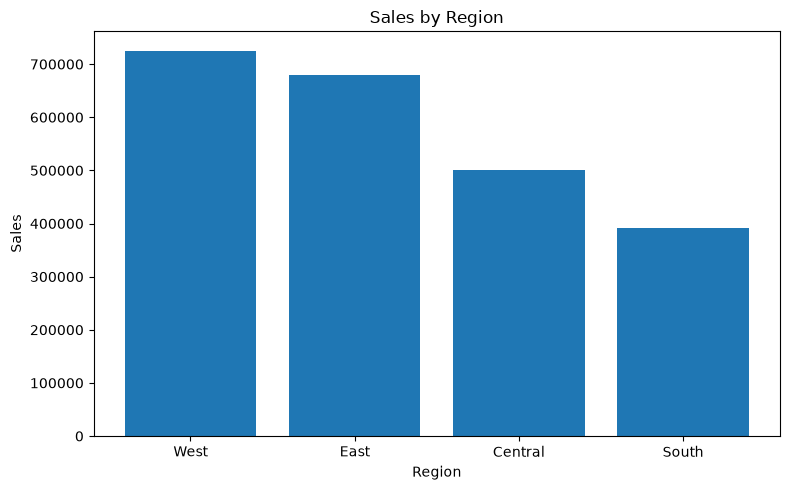

In [71]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis.index,
    region_analysis["sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

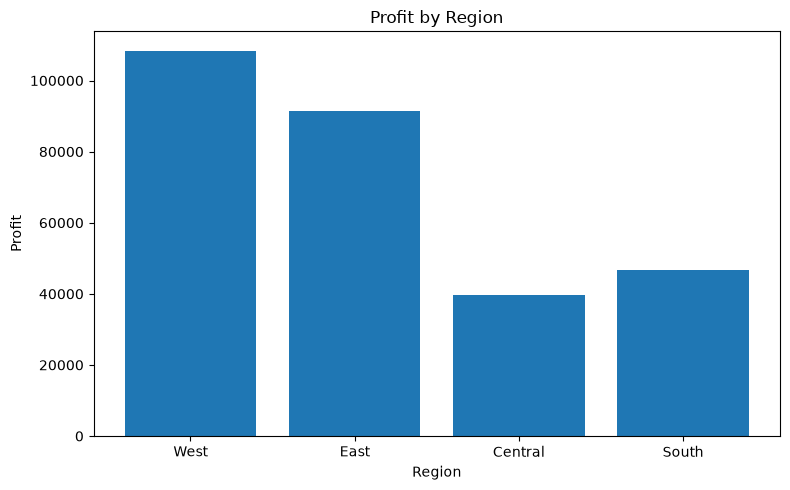

In [72]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis.index,
    region_analysis["profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [73]:
best_region = region_analysis.loc[
    region_analysis["profit"].idxmax()
]

best_region

sales       725457.8245
profit      108418.4489
orders        1611.0000
quantity     12266.0000
Name: West, dtype: float64

In [74]:
worst_region = region_analysis.loc[
    region_analysis["profit"].idxmin()
]

worst_region

sales       501239.8908
profit       39706.3625
orders        1175.0000
quantity      8780.0000
Name: Central, dtype: float64

In [75]:
state_analysis = (
    clean_df
    .groupby("state")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("sales", ascending=False)
)

state_analysis.head(10)

,sales,profit,orders,quantity
state,,,,
California,457687.6315,76381.3871,1021,7667
New York,310876.2710,74038.5486,562,4224
Texas,170188.0458,-25729.3563,487,3724
Washington,138641.2700,33402.6517,256,1883
Pennsylvania,116511.9140,-15559.9603,288,2153
Florida,89473.7080,-3399.3017,200,1379
Illinois,80166.1010,-12607.8870,276,1845
Ohio,78258.1360,-16971.3766,236,1759
Michigan,76269.6140,24463.1876,117,946


In [76]:
top_profit_states = state_analysis.sort_values(
    "profit",
    ascending=False
).head(10)

top_profit_states

,sales,profit,orders,quantity
state,,,,
California,457687.6315,76381.3871,1021,7667
New York,310876.2710,74038.5486,562,4224
Washington,138641.2700,33402.6517,256,1883
Michigan,76269.6140,24463.1876,117,946
Virginia,70636.7200,18597.9504,115,893
Indiana,53555.3600,18382.9363,73,578
Georgia,49095.8400,16250.0433,91,705
Kentucky,36591.7500,11199.6966,61,523
Minnesota,29863.1500,10823.1874,44,331


In [77]:
loss_making_states = state_analysis[
    state_analysis["profit"] < 0
].sort_values("profit")

loss_making_states

,sales,profit,orders,quantity
state,,,,
Texas,170188.0458,-25729.3563,487,3724
Ohio,78258.1360,-16971.3766,236,1759
Pennsylvania,116511.9140,-15559.9603,288,2153
Illinois,80166.1010,-12607.8870,276,1845
North Carolina,55603.1640,-7490.9122,136,983
Colorado,32108.1180,-6527.8579,79,693
Tennessee,30661.8730,-5341.6936,91,681
Arizona,35282.0010,-3427.9246,108,862
Florida,89473.7080,-3399.3017,200,1379


In [78]:
region_analysis["profit_margin"] = (
    region_analysis["profit"]
    / region_analysis["sales"]
) * 100

region_analysis.sort_values(
    "profit_margin",
    ascending=False
)

,sales,profit,orders,quantity,profit_margin
region,,,,,
West,725457.8245,108418.4489,1611,12266,14.944831
East,678781.2400,91522.7800,1401,10618,13.483399
South,391721.9050,46749.4303,822,6209,11.934342
Central,501239.8908,39706.3625,1175,8780,7.921629


In [79]:
segment_analysis = (
    clean_df
    .groupby("segment")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("sales", ascending=False)
)

segment_analysis

,sales,profit,orders,customers,quantity
segment,,,,,
Consumer,1.161401e+06,134119.2092,2586,409,19521
Corporate,7.061464e+05,91979.1340,1514,236,11608
Home Office,4.296531e+05,60298.6785,909,148,6744


In [80]:
segment_analysis["profit_margin"] = (
    segment_analysis["profit"]
    / segment_analysis["sales"]
) * 100

segment_analysis

,sales,profit,orders,customers,quantity,profit_margin
segment,,,,,,
Consumer,1.161401e+06,134119.2092,2586,409,19521,11.548050
Corporate,7.061464e+05,91979.1340,1514,236,11608,13.025506
Home Office,4.296531e+05,60298.6785,909,148,6744,14.034269


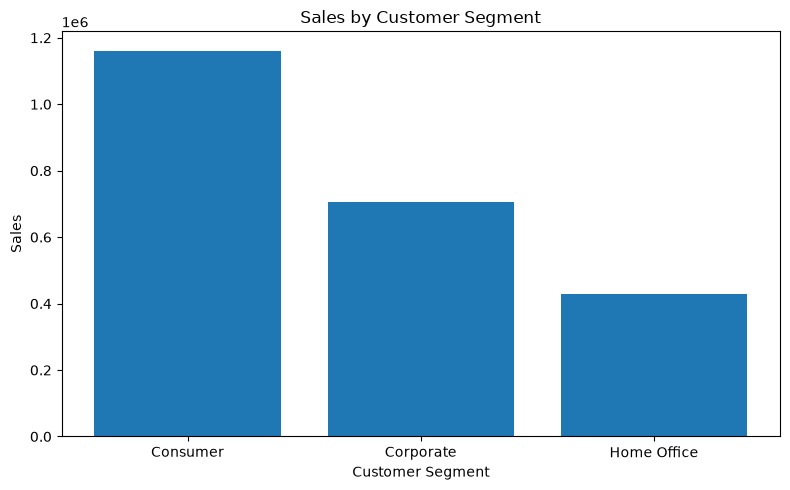

In [81]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis.index,
    segment_analysis["sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

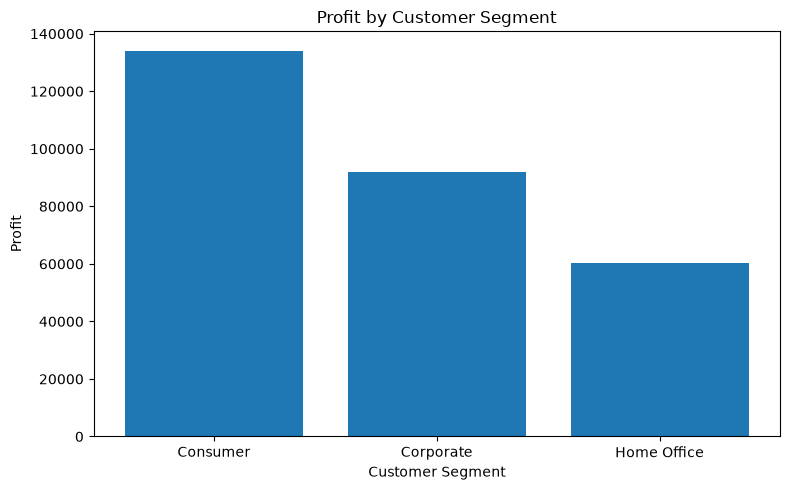

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis.index,
    segment_analysis["profit"]
)

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [83]:
customer_analysis = (
    clean_df
    .groupby(["customer_id", "customer_name"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("sales", ascending=False)
)

customer_analysis.head(10)

,,sales,profit,orders,quantity
customer_id,customer_name,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50
TC-20980,Tamara Chand,19052.218,8981.3239,5,42
RB-19360,Raymond Buch,15117.339,6976.0959,6,71
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36
AB-10105,Adrian Barton,14473.571,5444.8055,10,73
KL-16645,Ken Lonsdale,14175.229,806.8550,12,113
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50
SE-20110,Sanjit Engle,12209.438,2650.6769,11,78


In [84]:
top_profit_customers = (
    customer_analysis
    .sort_values("profit", ascending=False)
    .head(10)
)

top_profit_customers

,,sales,profit,orders,quantity
customer_id,customer_name,,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5,42
RB-19360,Raymond Buch,15117.339,6976.0959,6,71
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50
AB-10105,Adrian Barton,14473.571,5444.8055,10,73
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36
CM-12385,Christopher Martinez,8954.020,3899.8904,4,34
KD-16495,Keith Dawkins,8181.256,3038.6254,12,84
AR-10540,Andy Reiter,6608.448,2884.6208,6,33


In [85]:
loss_making_customers = (
    customer_analysis[
        customer_analysis["profit"] < 0
    ]
    .sort_values("profit")
)

loss_making_customers.head(10)

,,sales,profit,orders,quantity
customer_id,customer_name,,,,
CS-12505,Cindy Stewart,5690.055,-6626.3895,6,40
GT-14635,Grant Thornton,9351.212,-4108.6589,3,26
LF-17185,Luke Foster,3930.509,-3583.9770,7,69
SR-20425,Sharelle Roach,3233.481,-3333.9144,5,34
HG-14965,Henry Goldwyn,3247.642,-2797.9635,12,68
NC-18415,Nathan Cano,2218.990,-2204.8072,6,38
SB-20290,Sean Braxton,8057.891,-2082.7451,7,84
SM-20320,Sean Miller,25043.050,-1980.7393,5,50
CP-12340,Christine Phan,5888.275,-1850.3029,8,59


In [86]:
discount_analysis = (
    clean_df
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_index()
)

discount_analysis

,sales,profit,orders,quantity
discount,,,,
0.00,1.087908e+06,320987.6032,2644,18267
0.10,5.436935e+04,9029.1770,89,373
0.15,2.755852e+04,1418.9915,51,198
0.20,7.645944e+05,90337.3060,2407,13660
0.30,1.032267e+05,-10369.2774,211,849
0.32,1.449346e+04,-2391.1377,27,105
0.40,1.164178e+05,-23057.0504,185,786
0.45,5.484974e+03,-2493.1111,10,45
0.50,5.891854e+04,-20506.4281,64,241


In [87]:
discount_analysis["profit_margin"] = (
    discount_analysis["profit"]
    / discount_analysis["sales"]
) * 100

discount_analysis

,sales,profit,orders,quantity,profit_margin
discount,,,,,
0.00,1.087908e+06,320987.6032,2644,18267,29.505019
0.10,5.436935e+04,9029.1770,89,373,16.607108
0.15,2.755852e+04,1418.9915,51,198,5.149012
0.20,7.645944e+05,90337.3060,2407,13660,11.815063
0.30,1.032267e+05,-10369.2774,211,849,-10.045155
0.32,1.449346e+04,-2391.1377,27,105,-16.498047
0.40,1.164178e+05,-23057.0504,185,786,-19.805437
0.45,5.484974e+03,-2493.1111,10,45,-45.453472
0.50,5.891854e+04,-20506.4281,64,241,-34.804712


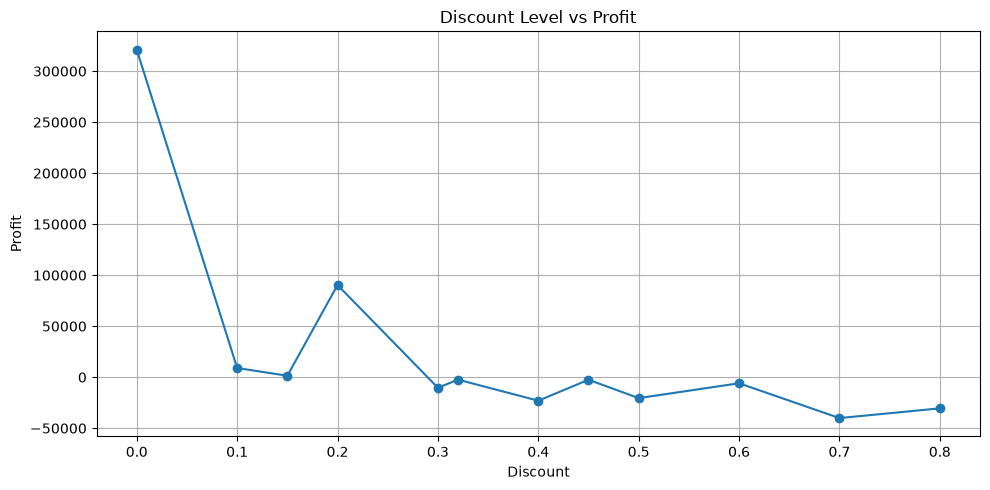

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_analysis.index,
    discount_analysis["profit"],
    marker="o"
)

plt.title("Discount Level vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)
plt.tight_layout()

plt.show()

In [89]:
category_discount = (
    clean_df
    .groupby(["category", "discount"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

category_discount.head(20)

,category,discount,sales,profit,orders
0,Furniture,0.00,256025.2700,58133.0764,739
1,Furniture,0.10,46634.2470,7111.0119,71
2,Furniture,0.15,27558.5215,1418.9915,51
3,Furniture,0.20,216631.0160,6265.9491,539
4,Furniture,0.30,99470.3500,-10695.3169,207
5,Furniture,0.32,14493.4588,-2391.1377,27
6,Furniture,0.40,45614.4060,-16187.3968,72
7,Furniture,0.45,5484.9740,-2493.1111,10
8,Furniture,0.50,20983.4700,-12871.1990,53
9,Furniture,0.60,6644.7000,-5944.6552,127


In [90]:
negative_category_discount = category_discount[
    category_discount["profit"] < 0
].sort_values("profit")

negative_category_discount

,category,discount,sales,profit,orders
15,Office Supplies,0.80,16963.7560,-30539.0392,250
22,Technology,0.70,15601.5090,-19579.3191,22
14,Office Supplies,0.70,22559.3910,-16601.0984,323
6,Furniture,0.40,45614.4060,-16187.3968,72
8,Furniture,0.50,20983.4700,-12871.1990,53
4,Furniture,0.30,99470.3500,-10695.3169,207
21,Technology,0.50,37935.0700,-7635.2291,11
20,Technology,0.40,70803.3780,-6869.6536,118
9,Furniture,0.60,6644.7000,-5944.6552,127
10,Furniture,0.70,2459.3820,-3894.9394,15


In [91]:
worst_discount = discount_analysis.loc[
    discount_analysis["profit"].idxmin()
]

worst_discount

sales            40620.28200
profit          -40075.35690
orders             344.00000
quantity          1660.00000
profit_margin      -98.65849
Name: 0.7, dtype: float64

In [92]:
best_discount = discount_analysis.loc[
    discount_analysis["profit"].idxmax()
]

best_discount

sales            1.087908e+06
profit           3.209876e+05
orders           2.644000e+03
quantity         1.826700e+04
profit_margin    2.950502e+01
Name: 0.0, dtype: float64

In [93]:
subcategory_analysis = (
    clean_df
    .groupby("sub-category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        products=("product_id", "nunique")
    )
    .sort_values("sales", ascending=False)
)

subcategory_analysis

,sales,profit,quantity,orders,products
sub-category,,,,,
Phones,330007.0540,44515.7306,3289,814,184
Chairs,328449.1030,26590.1663,2356,576,87
Storage,223843.6080,21278.8264,3158,777,131
Tables,206965.5320,-17725.4811,1241,307,57
Binders,203412.7330,30221.7633,5974,1316,210
Machines,189238.6310,3384.7569,440,112,63
Accessories,167380.3180,41936.6357,2976,718,144
Copiers,149528.0300,55617.8249,234,68,13
Bookcases,114879.9963,-3472.5560,868,224,49


In [94]:
subcategory_analysis["profit_margin"] = (
    subcategory_analysis["profit"]
    / subcategory_analysis["sales"]
) * 100

subcategory_analysis.sort_values(
    "profit_margin",
    ascending=False
)

,sales,profit,quantity,orders,products,profit_margin
sub-category,,,,,,
Labels,12486.3120,5546.2540,1400,346,70,44.418672
Paper,78479.2060,34053.5693,5178,1191,276,43.391837
Envelopes,16476.4020,6964.1767,906,249,54,42.267582
Copiers,149528.0300,55617.8249,234,68,13,37.195585
Fasteners,3024.2800,949.5182,914,215,43,31.396504
Accessories,167380.3180,41936.6357,2976,718,144,25.054700
Art,27118.7920,6527.7870,3000,731,163,24.071083
Appliances,107532.1610,18138.0054,1729,451,98,16.867517
Binders,203412.7330,30221.7633,5974,1316,210,14.857361


In [95]:
top_profit_subcategories = (
    subcategory_analysis
    .sort_values("profit", ascending=False)
    .head(10)
)

top_profit_subcategories

,sales,profit,quantity,orders,products,profit_margin
sub-category,,,,,,
Copiers,149528.030,55617.8249,234,68,13,37.195585
Phones,330007.054,44515.7306,3289,814,184,13.489327
Accessories,167380.318,41936.6357,2976,718,144,25.054700
Paper,78479.206,34053.5693,5178,1191,276,43.391837
Binders,203412.733,30221.7633,5974,1316,210,14.857361
Chairs,328449.103,26590.1663,2356,576,87,8.095673
Storage,223843.608,21278.8264,3158,777,131,9.506113
Appliances,107532.161,18138.0054,1729,451,98,16.867517
Furnishings,91705.164,13059.1436,3563,877,182,14.240358


In [96]:
worst_profit_subcategories = (
    subcategory_analysis
    .sort_values("profit")
    .head(10)
)

worst_profit_subcategories

,sales,profit,quantity,orders,products,profit_margin
sub-category,,,,,,
Tables,206965.5320,-17725.4811,1241,307,57,-8.564460
Bookcases,114879.9963,-3472.5560,868,224,49,-3.022768
Supplies,46673.5380,-1189.0995,647,187,38,-2.547695
Fasteners,3024.2800,949.5182,914,215,43,31.396504
Machines,189238.6310,3384.7569,440,112,63,1.788618
Labels,12486.3120,5546.2540,1400,346,70,44.418672
Art,27118.7920,6527.7870,3000,731,163,24.071083
Envelopes,16476.4020,6964.1767,906,249,54,42.267582
Furnishings,91705.1640,13059.1436,3563,877,182,14.240358


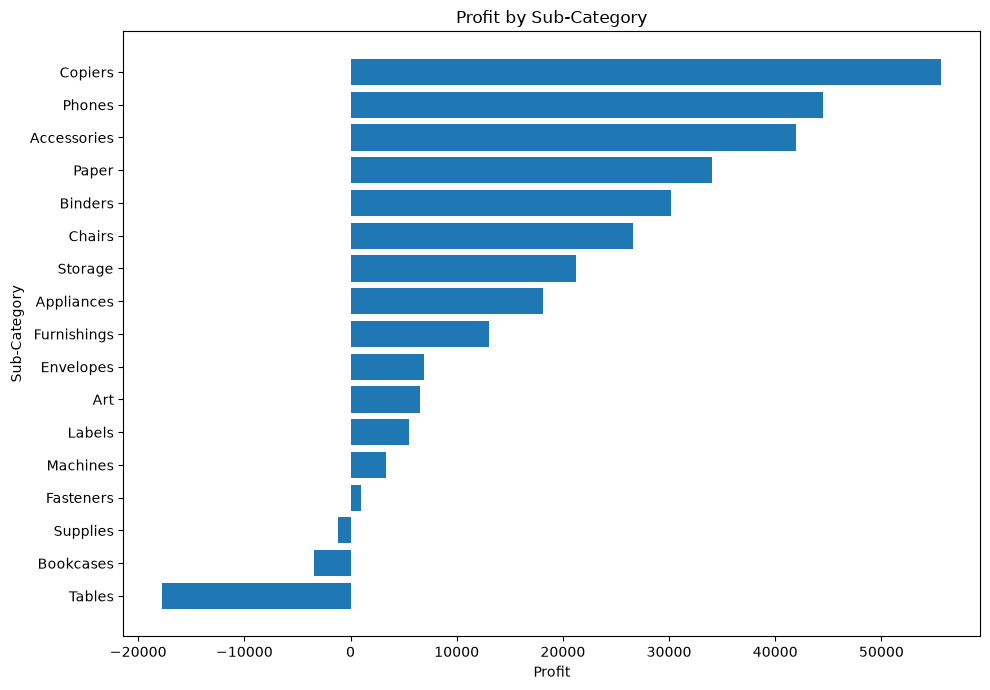

In [97]:
profit_chart = subcategory_analysis.sort_values(
    "profit",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    profit_chart.index,
    profit_chart["profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [98]:
top_products = (
    product_analysis
    .sort_values("profit", ascending=False)
    .head(10)
)

top_products

,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31,10
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12,3
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24,7
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3


In [99]:
worst_products = (
    product_analysis
    .sort_values("profit")
    .head(10)
)

worst_products

,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27,5
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33,7
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6,1
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22,6
FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4


In [100]:
product_sales_profit = product_analysis[
    ["sales", "profit"]
].sort_values(
    "sales",
    ascending=False
)

product_sales_profit.head(10)

,,sales,profit
product_id,product_name,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03


In [101]:
high_sales_low_profit = product_analysis[
    (product_analysis["sales"] > product_analysis["sales"].median()) &
    (product_analysis["profit"] < product_analysis["profit"].median())
].sort_values(
    "profit"
)

high_sales_low_profit.head(10)

,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27,5
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33,7
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6,1
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22,6
FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4


In [102]:
print("===== BUSINESS ANALYSIS SUMMARY =====")

print(f"Total Sales: ${clean_df['sales'].sum():,.2f}")
print(f"Total Profit: ${clean_df['profit'].sum():,.2f}")
print(f"Total Orders: {clean_df['order_id'].nunique():,}")
print(f"Total Customers: {clean_df['customer_id'].nunique():,}")

print("\nBest Region:")
print(best_region)

print("\nWorst Region:")
print(worst_region)

print("\nBest Sales Month:")
print(best_sales_month)

print("\nBest Profit Month:")
print(best_profit_month)

print("\nWorst Profit Month:")
print(worst_profit_month)

===== BUSINESS ANALYSIS SUMMARY =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793

Best Region:
sales       725457.8245
profit      108418.4489
orders        1611.0000
quantity     12266.0000
Name: West, dtype: float64

Worst Region:
sales       501239.8908
profit       39706.3625
orders        1175.0000
quantity      8780.0000
Name: Central, dtype: float64

Best Sales Month:
year                     2017
month                      11
sales              118447.825
profit              9690.1037
orders                    261
date      2017-11-01 00:00:00
Name: 46, dtype: object

Best Profit Month:
year                     2016
month                      12
sales               96999.043
profit             17885.3093
orders                    176
date      2016-12-01 00:00:00
Name: 35, dtype: object

Worst Profit Month:
year                     2015
month                       1
sales              18174.0756
profit              -3281.007
or

In [103]:
discount_profit_corr = clean_df["discount"].corr(
    clean_df["profit"]
)

print(
    f"Correlation between Discount and Profit: "
    f"{discount_profit_corr:.3f}"
)

Correlation between Discount and Profit: -0.219


In [104]:
sales_profit_corr = clean_df["sales"].corr(
    clean_df["profit"]
)

print(
    f"Correlation between Sales and Profit: "
    f"{sales_profit_corr:.3f}"
)

Correlation between Sales and Profit: 0.479


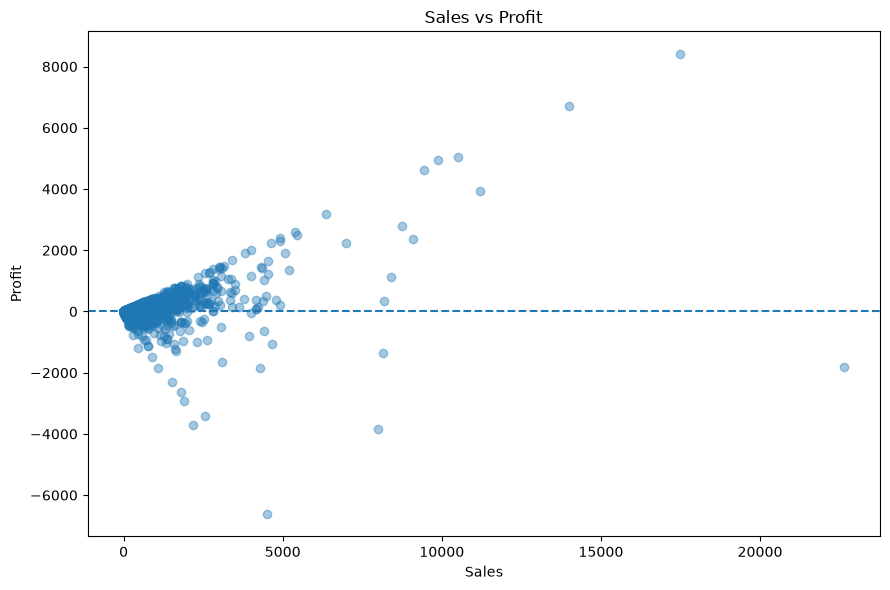

In [105]:
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["sales"],
    clean_df["profit"],
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [106]:
high_sales_losses = clean_df[
    (clean_df["sales"] > clean_df["sales"].quantile(0.90)) &
    (clean_df["profit"] < 0)
].sort_values(
    "profit"
)

high_sales_losses[
    [
        "order_id",
        "customer_name",
        "category",
        "sub-category",
        "sales",
        "discount",
        "profit"
    ]
].head(10)

,order_id,customer_name,category,sub-category,sales,discount,profit
7772,CA-2016-108196,Cindy Stewart,Technology,Machines,4499.985,0.7,-6599.9780
683,US-2017-168116,Grant Thornton,Technology,Machines,7999.980,0.5,-3839.9904
9774,CA-2014-169019,Luke Foster,Office Supplies,Binders,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Sharelle Roach,Technology,Machines,2549.985,0.7,-3399.9800
4991,US-2017-122714,Henry Goldwyn,Office Supplies,Binders,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Natalie Fritzler,Technology,Machines,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Nathan Cano,Office Supplies,Binders,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Joseph Holt,Furniture,Tables,4297.644,0.4,-1862.3124
1199,CA-2016-130946,Zuschuss Carroll,Office Supplies,Binders,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Sean Miller,Technology,Machines,22638.480,0.5,-1811.0784


In [107]:
high_profit_orders = clean_df.sort_values(
    "profit",
    ascending=False
)

high_profit_orders[
    [
        "order_id",
        "customer_name",
        "category",
        "sub-category",
        "sales",
        "discount",
        "profit"
    ]
].head(10)

,order_id,customer_name,category,sub-category,sales,discount,profit
6826,CA-2016-118689,Tamara Chand,Technology,Copiers,17499.950,0.0,8399.9760
8153,CA-2017-140151,Raymond Buch,Technology,Copiers,13999.960,0.0,6719.9808
4190,CA-2017-166709,Hunter Lopez,Technology,Copiers,10499.970,0.0,5039.9856
9039,CA-2016-117121,Adrian Barton,Office Supplies,Binders,9892.740,0.0,4946.3700
4098,CA-2014-116904,Sanjit Chand,Office Supplies,Binders,9449.950,0.0,4630.4755
2623,CA-2017-127180,Tom Ashbrook,Technology,Copiers,11199.968,0.2,3919.9888
509,CA-2015-145352,Christopher Martinez,Office Supplies,Binders,6354.950,0.0,3177.4750
8488,CA-2016-158841,Sanjit Engle,Technology,Machines,8749.950,0.0,2799.9840
7666,US-2016-140158,Daniel Raglin,Technology,Copiers,5399.910,0.0,2591.9568
6520,CA-2017-138289,Andy Reiter,Office Supplies,Binders,5443.960,0.0,2504.2216


In [108]:
final_insights = pd.DataFrame({
    "Metric": [
        "Best Region",
        "Weakest Region",
        "Highest Sales Month",
        "Highest Profit Month",
        "Lowest Profit Month",
        "Highest Profit State",
        "Major Loss-Making State"
    ],
    "Finding": [
        best_region.name,
        worst_region.name,
        best_sales_month["date"].strftime("%B %Y"),
        best_profit_month["date"].strftime("%B %Y"),
        worst_profit_month["date"].strftime("%B %Y"),
        top_profit_states.index[0],
        loss_making_states.index[0]
    ]
})

final_insights

,Metric,Finding
0,Best Region,West
1,Weakest Region,Central
2,Highest Sales Month,November 2017
3,Highest Profit Month,December 2016
4,Lowest Profit Month,January 2015
5,Highest Profit State,California
6,Major Loss-Making State,Texas
